<a href="https://colab.research.google.com/github/azarizz/ta/blob/main/aaaaa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [4]:
from google_play_scraper import app, reviews, Sort
import pandas as pd

# ID Aplikasi MyTelkomsel
app_id = 'com.telkomsel.telkomselcm'

# Ambil metadata aplikasi termasuk versi terbaru
app_info = app(app_id, lang='id', country='id')
latest_version = app_info['version']
print("Versi Terbaru:", latest_version)

# Scraping komentar (ulasan terbaru)
all_reviews = []
cursor = None
total = 0
max_reviews = 200  # bisa kamu ubah sesuai kebutuhan

while total < max_reviews:
    r, cursor = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=2000,       # ambil 100 per halaman
        continuation_token=cursor
    )

    # Filter hanya komentar dari versi terbaru
    filtered = [x for x in r if x.get('reviewCreatedVersion') == latest_version]
    all_reviews.extend(filtered)

    total = len(all_reviews)
    print(f"✅ {len(filtered)} komentar dari versi {latest_version} ditambahkan, total: {total}")

    if not cursor or len(filtered) == 0:
        break

# Simpan ke DataFrame
df_filtered = pd.DataFrame(all_reviews)[['userName', 'at', 'content', 'reviewCreatedVersion']]
df_filtered.rename(columns={'userName': 'user', 'at': 'date', 'content': 'komentar'}, inplace=True)

# Simpan ke CSV
df_filtered.to_csv("dataset_playstore_terbaru.csv", index=False)
print("✅ Komentar dari versi terbaru berhasil disimpan ke dataset_playstore_terbaru.csv")


Versi Terbaru: 8.7.0
✅ 1313 komentar dari versi 8.7.0 ditambahkan, total: 1313
✅ Komentar dari versi terbaru berhasil disimpan ke dataset_playstore_terbaru.csv


In [ ]:
pip install selenium beautifulsoup4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 28.9 MB/s eta 0:00:00


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time
import pandas as pd

# --- KONFIGURASI ---
CHROMEDRIVER_PATH = '/path/to/chromedriver'  # ← ganti dengan path ChromeDriver kamu
INSTAGRAM_URL = 'https://www.instagram.com/p/C3XgYB6rABC/'  # ← ganti dengan link postingan
MAX_COMMENTS = 100

# --- INISIALISASI DRIVER ---
options = webdriver.ChromeOptions()
options.add_argument("--headless")  # Hilangkan jika ingin melihat browsernya
options.add_argument('--disable-blink-features=AutomationControlled')
driver = webdriver.Chrome(service=Service(CHROMEDRIVER_PATH), options=options)

# --- AKSES POSTINGAN ---
driver.get(INSTAGRAM_URL)
time.sleep(5)

# --- LOAD KOMENTAR SECARA OTOMATIS ---
print("🔄 Memuat komentar...")
while True:
    try:
        load_more = driver.find_element(By.XPATH, "//button[contains(text(), 'Lihat komentar lainnya')]")
        load_more.click()
        time.sleep(2)
    except:
        break  # Tidak ada tombol lagi

# --- PARSING HTML DENGAN BEAUTIFULSOUP ---
soup = BeautifulSoup(driver.page_source, 'html.parser')
driver.quit()

# --- AMBIL KOMENTAR ---
comments = []
for comment in soup.find_all('ul'):
    spans = comment.find_all('span')
    if len(spans) >= 2:
        username = spans[0].text.strip()
        komentar = spans[1].text.strip()
        if username and komentar:
            comments.append({'user': username, 'komentar': komentar})
    if len(comments) >= MAX_COMMENTS:
        break

# --- SIMPAN KE CSV ---
df = pd.DataFrame(comments)
df.to_csv("komentar_instagram_public.csv", index=False)
print(f"✅ {len(df)} komentar disimpan ke komentar_instagram_public.csv")


❌ Gagal load session. Jalankan penyimpanan session dulu.
🔍 Mengambil postingan dari hashtag #mytelkomsel


JSON Query to api/v1/tags/web_info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/tags/web_info/?__a=1&__d=dis&tag_name=mytelkomsel [retrying; skip with ^C]
JSON Query to api/v1/tags/web_info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/tags/web_info/?__a=1&__d=dis&tag_name=mytelkomsel [retrying; skip with ^C]


ConnectionException: JSON Query to api/v1/tags/web_info/: 403 Forbidden - "fail" status, message "login_required" when accessing https://i.instagram.com/api/v1/tags/web_info/?__a=1&__d=dis&tag_name=mytelkomsel

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn Sastrawi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.6 MB/s eta 0:00:00



==== Evaluasi dengan METRIK: EUCLIDEAN ====
Akurasi: 0.5074183976261127
              precision    recall  f1-score   support

     negatif       0.92      0.11      0.20       109
      netral       0.47      0.99      0.63       145
     positif       1.00      0.18      0.31        83

    accuracy                           0.51       337
   macro avg       0.80      0.43      0.38       337
weighted avg       0.75      0.51      0.41       337



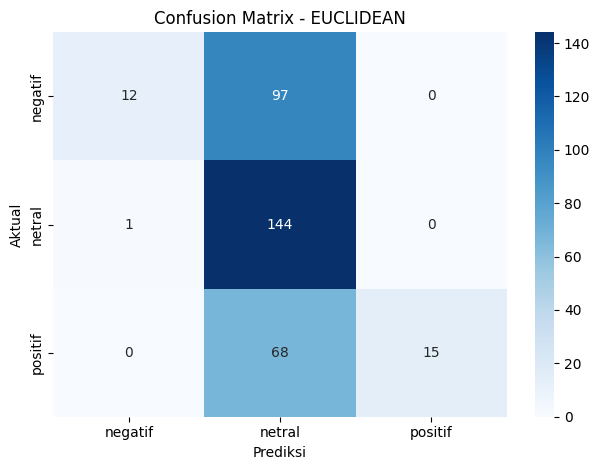


==== Evaluasi dengan METRIK: MANHATTAN ====
Akurasi: 0.456973293768546
              precision    recall  f1-score   support

     negatif       1.00      0.03      0.05       109
      netral       0.44      1.00      0.61       145
     positif       1.00      0.07      0.13        83

    accuracy                           0.46       337
   macro avg       0.81      0.37      0.27       337
weighted avg       0.76      0.46      0.31       337



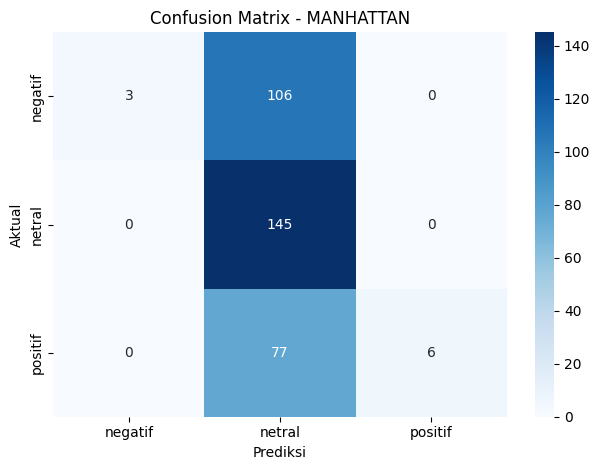


==== Evaluasi dengan METRIK: COSINE ====
Akurasi: 0.6498516320474778
              precision    recall  f1-score   support

     negatif       0.60      0.75      0.67       109
      netral       0.64      0.65      0.64       145
     positif       0.83      0.52      0.64        83

    accuracy                           0.65       337
   macro avg       0.69      0.64      0.65       337
weighted avg       0.67      0.65      0.65       337



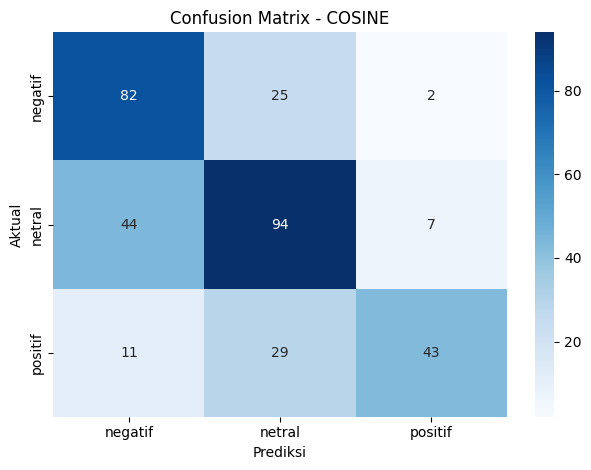

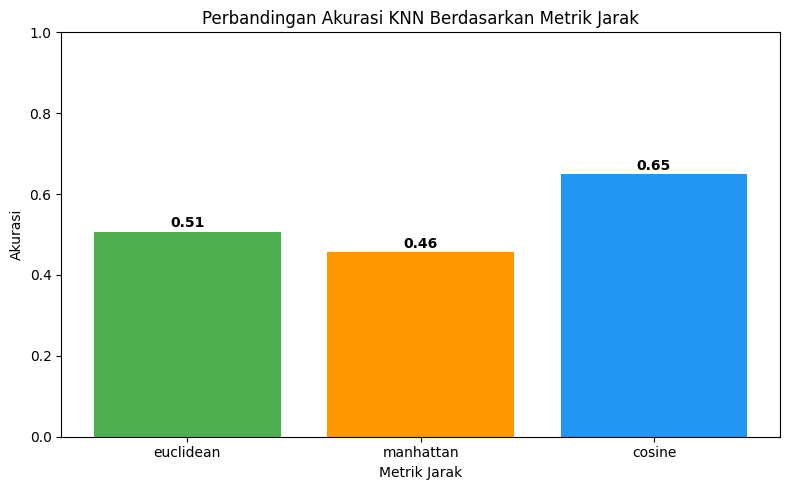

In [9]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# =============================
# 1. Lexicon Lengkap dan Skoring
# =============================
lexicon_positif = [
    'baik', 'bagus', 'mantap', 'puas', 'cepat', 'mudah', 'ramah', 'senang', 'lancar',
    'top', 'memuaskan', 'menyenangkan', 'terbaik', 'cukup', 'bekerja', 'bantu', 'bisa',
    'suka', 'komplit', 'beres', 'terjangkau', 'efisien', 'responsif', 'keren',
    'rekomendasi', 'hebat', 'jempol', 'ok', 'sukses', 'inovatif', 'andalan', 'praktis',
    'stabil', 'aman', 'support', 'solutif'
]

lexicon_negatif = [
    'buruk', 'jelek', 'lemot', 'lambat', 'tidak', 'kurang', 'gagal', 'error', 'macet',
    'lama', 'susah', 'mengecewakan', 'kecewa', 'ribet', 'parah', 'menurun', 'gangguan',
    'lelet', 'tidak bisa', 'tidak stabil', 'tidak responsif', 'bermasalah', 'kacau',
    'rusak', 'hilang', 'hang', 'lag', 'uninstall', 'crash', 'sampah', 'bohong',
    'tidak jelas', 'mahal', 'lemah', 'emosi', 'tidak rekomendasi'
]

lexicon = {}
for word in lexicon_positif:
    lexicon[word] = 1
for word in lexicon_negatif:
    lexicon[word] = -1

def lexicon_score(text):
    score = sum([lexicon.get(word, 0) for word in text.split()])
    if score > 0:
        return 'positif'
    elif score < 0:
        return 'negatif'
    else:
        return 'netral'

# =============================
# 2. Preprocessing Function
# =============================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  # Hilangkan simbol dan angka
    text = text.lower()
    tokens = text.split()
    stemmed = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed)

# =============================
# 3. Load dan Siapkan Dataset
# =============================
df1 = pd.read_csv("dataset_playstore_terbaru.csv")
df2 = pd.read_csv("IG_Comments_Formatted_Like_PlayStore.csv")

# Ensure both dataframes have a 'komentar' column before concatenating
# The playstore data already has it due to renaming
# For the Instagram data, you need to rename the column containing comments
# Assuming the comment column in IG_Comments_Formatted_Like_PlayStore.csv is named 'komentar' based on the previous code
# If the column name is different, e.g., 'content' or 'text', change 'komentar' below accordingly
if 'komentar' not in df2.columns:
     # Assuming the column containing comments in df2 is 'komentar'. Adjust if necessary.
    df2.rename(columns={'komentar': 'komentar'}, inplace=True) # <-- Jika nama kolom komentar di df2 BUKAN 'komentar', ubah key di sini

df_all = pd.concat([df1, df2], ignore_index=True)

# Tambahkan kolom 'clean_text' dan 'label' berdasarkan lexicon
# Use the correct column name 'komentar' instead of 'ulasan'
df_all['clean_text'] = df_all['komentar'].apply(preprocess)
df_all['label'] = df_all['clean_text'].apply(lexicon_score)

df_all.to_csv("dataset.csv", index=False)

# =============================
# 4. TF-IDF, Encode Labels, dan Split Data
# =============================
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_all['clean_text'])

# Encode string labels to numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_all['label']) # Fit and transform the labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================
# 5. Evaluasi KNN dengan 3 Metrik
# =============================
metrics = {
    'euclidean': 'euclidean',
    'manhattan': 'manhattan',
    'cosine': 'cosine'
}
accuracy_scores = []

# Get the original label names to use in the confusion matrix and classification report
# The order should match the sorted unique labels after encoding
original_labels = label_encoder.classes_

for name, metric in metrics.items():
    print(f"\n==== Evaluasi dengan METRIK: {name.upper()} ====")
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append((name, acc))

    print("Akurasi:", acc)

    # Classification report requires original labels for readability
    print(classification_report(y_test, y_pred, target_names=original_labels))

    # Confusion Matrix also needs original labels for plotting
    cm = confusion_matrix(y_test, y_pred, labels=label_encoder.transform(original_labels)) # Pass numerical labels to confusion_matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=original_labels,
                yticklabels=original_labels)
    plt.title(f"Confusion Matrix - {name.upper()}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.show()

# =============================
# 6. Visualisasi Perbandingan Akurasi
# =============================
metrik_labels, akurasi_nilai = zip(*accuracy_scores)

plt.figure(figsize=(8,5))
plt.bar(metrik_labels, akurasi_nilai, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Perbandingan Akurasi KNN Berdasarkan Metrik Jarak")
plt.xlabel("Metrik Jarak")
plt.ylabel("Akurasi")
plt.ylim(0, 1)
for i, v in enumerate(akurasi_nilai):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()